# Cluster Exploration

Inspects chunk-level clusters from `chunk_cluster_labels`. Each row is one semantic chunk including noise (`cluster_id = -1`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import umap as umap_lib
from sklearn.feature_extraction.text import TfidfVectorizer
from pathlib import Path
import sys

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120

_nb_file = globals().get('__vsc_ipynb_file__', None)
if _nb_file:
    REPO_ROOT = Path(_nb_file).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else (
                _cwd.parent if (_cwd.parent / 'gcp_config.py').exists() else _cwd)
DATA_DIR = REPO_ROOT / 'data'
FIGURES_DIR = DATA_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'DATA_DIR: {DATA_DIR}')

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

df = client.query(f"""
    SELECT
        cl.chunk_uid, cl.conversation_id, cl.cluster_id, cl.is_noise,
        cl.hdbscan_prob AS membership_prob, cl.umap_x, cl.umap_y,
        cl.detected_language,
        cl.original_chunk_text AS chunk_text
    FROM `{bq_table('chunk_cluster_labels')}` cl
    ORDER BY cl.chunk_uid
""").to_dataframe()

TRACK    = 'multilingual'
lbl      = 'Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d)'
TEXT_COL = 'chunk_text'

n_clust = df[df.cluster_id >= 0].cluster_id.nunique()
n_noise = (df['cluster_id'] == -1).sum()
print(f'Chunk pipeline: {len(df):,} chunks | clusters={n_clust} | noise chunks={n_noise} ({100*n_noise/len(df):.1f}%)')

def compute_vis_umap(embeds, df_labels):
    MAX_PER_CLUSTER = 2000
    rng = np.random.default_rng(42)
    fit_pos = []
    for cid in df_labels.cluster_id.unique():
        pos = np.where(df_labels.cluster_id.values == cid)[0]
        fit_pos.extend(rng.choice(pos, min(MAX_PER_CLUSTER, len(pos)), replace=False).tolist())
    fit_pos = np.array(sorted(fit_pos))
    reducer = umap_lib.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.4,
        spread=2.5, metric='cosine', random_state=42, verbose=False
    )
    reducer.fit(embeds[fit_pos])
    coords = reducer.transform(embeds)
    return coords

emb_base_file = DATA_DIR / 'chunk_embeddings_multilingual.npy'
emb_fine_file = DATA_DIR / 'chunk_embeddings_finetuned.npy'

if emb_base_file.exists():
    print(f'\nLoading base embeddings...')
    embeds_base = np.load(emb_base_file)
    print(f'Fitting visualization UMAP (base)...')
    coords_base = compute_vis_umap(embeds_base, df)
    df['vis_x_base'] = coords_base[:, 0]
    df['vis_y_base'] = coords_base[:, 1]
    print('Base UMAP done.')
else:
    df['vis_x_base'] = df['umap_x']
    df['vis_y_base'] = df['umap_y']

if emb_fine_file.exists():
    print(f'\nLoading finetuned embeddings...')
    embeds_fine = np.load(emb_fine_file)
    print(f'Fitting visualization UMAP (finetuned)...')
    coords_fine = compute_vis_umap(embeds_fine, df)
    df['vis_x_fine'] = coords_fine[:, 0]
    df['vis_y_fine'] = coords_fine[:, 1]
    print('Finetuned UMAP done.')
else:
    df['vis_x_fine'] = df['umap_x']
    df['vis_y_fine'] = df['umap_y']



DATA_DIR: /home/jupyter/support-analytics/data
Chunk pipeline: 169,709 chunks | clusters=24 | noise chunks=20346 (12.0%)

Loading base embeddings...
Fitting visualization UMAP (base)...


/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Base UMAP done.

Loading finetuned embeddings...
Fitting visualization UMAP (finetuned)...


/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Finetuned UMAP done.


In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

NAVY  = '#223459'
LIGHT = '#EAF0F4'
GREY  = '#7A8A99'
DARK  = '#111111'

FIG_W = 16.82
FIG_H = 2.72

STAGES = [
    ('Raw message data',      '1,007k messages\n46,445 conversations'),
    ('De-identification',     'SHA-256 IDs\nRegex + Presidio NER'),
    ('Semantic chunking',     'Coherence threshold\n169,709 chunks'),
    ('Initial embedding',     'BigQuery ML\ntext-multilingual-embed-002\n(768-D)'),
    ('Contrastive fine-tune', 'MiniLM-L12-v2 + MNRL\n2 bootstrap rounds\n(384-D)'),
    ('UMAP + HDBSCAN',        '10-D UMAP\n24 intent clusters'),
    ('Cluster labelling',     'Gemini 2.5 Flash\ntitle + theme + action'),
    ('Downstream analyses',   'Failure taxonomy\nTrends + Forecasting'),
]

n     = len(STAGES)
PAD   = 0.18
GAP   = 0.22
BOX_W = (FIG_W - 2*PAD - (n-1)*GAP) / n
BOX_H = 1.80
y_c   = FIG_H / 2

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, FIG_H)
ax.axis('off')

for i, (title, subtitle) in enumerate(STAGES):
    x0 = PAD + i * (BOX_W + GAP)
    xc = x0 + BOX_W / 2
    ax.add_patch(FancyBboxPatch(
        (x0, y_c - BOX_H / 2), BOX_W, BOX_H,
        boxstyle='round,pad=0.04,rounding_size=0.12',
        facecolor=LIGHT, edgecolor=NAVY, linewidth=1.0, zorder=2,
    ))
    n_sub   = subtitle.count('\n') + 1
    title_y = y_c + 0.05 + (n_sub - 1) * 0.045
    sub_y   = y_c - 0.16 - (n_sub - 2) * 0.045
    ax.text(xc, title_y, title,
            ha='center', va='center', fontsize=7.5, fontweight='bold',
            color=NAVY, zorder=3)
    ax.text(xc, sub_y, subtitle,
            ha='center', va='center', fontsize=6.5,
            color=DARK, zorder=3, linespacing=1.3)
    if i < n - 1:
        x_tail = x0 + BOX_W + 0.03
        x_head = x0 + BOX_W + GAP - 0.03
        ax.add_patch(FancyArrowPatch(
            (x_tail, y_c), (x_head, y_c),
            arrowstyle='-|>', mutation_scale=9,
            linewidth=1.0, color=GREY, zorder=1,
        ))

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig(FIGURES_DIR / 'pipeline_plot.png', dpi=300, facecolor='white')
plt.close(fig)
print('Saved: pipeline_plot.png')

In [2]:
titles_df = client.query(f"""
    SELECT cluster_id, cluster_title, n_chunks
    FROM `{bq_table('chunk_cluster_descriptions')}`
    ORDER BY cluster_id
""").to_dataframe()
titles_dict = dict(zip(titles_df['cluster_id'], titles_df['cluster_title']))
top5_cids = titles_df.nlargest(5, 'n_chunks')['cluster_id'].tolist()
print(f"Loaded {len(titles_df)} cluster titles")
print("Top-5 by chunk count:")
for cid in top5_cids:
    print(f"  C{cid}: {titles_dict[cid]}")

Loaded 24 cluster titles
Top-5 by chunk count:
  C11: Domain Purchase and Registration
  C8: Human Agent Escalation Requests
  C20: Website Down HTTP Error Diagnosis
  C16: AI Builder Site Generation Editing
  C13: Account and WordPress Login


## 1. Cluster size distribution

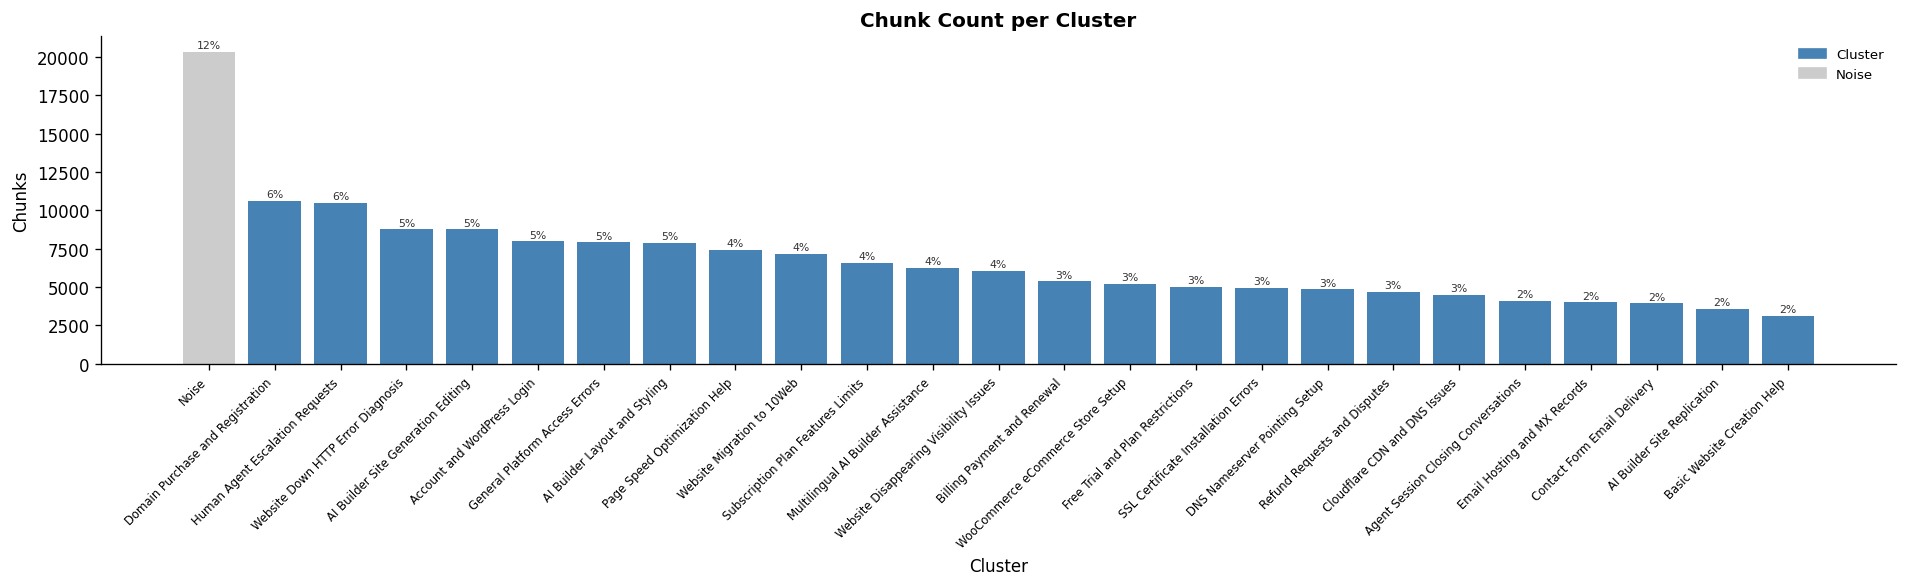


Chunk pipeline cluster sizes:
                                 label  count  pct
                                 Noise  20346 12.0
      Domain Purchase and Registration  10609  6.3
       Human Agent Escalation Requests  10499  6.2
     Website Down HTTP Error Diagnosis   8774  5.2
    AI Builder Site Generation Editing   8763  5.2
           Account and WordPress Login   7998  4.7
        General Platform Access Errors   7926  4.7
         AI Builder Layout and Styling   7900  4.7
          Page Speed Optimization Help   7434  4.4
            Website Migration to 10Web   7152  4.2
     Subscription Plan Features Limits   6573  3.9
    Multilingual AI Builder Assistance   6261  3.7
Website Disappearing Visibility Issues   6068  3.6
           Billing Payment and Renewal   5388  3.2
     WooCommerce eCommerce Store Setup   5213  3.1
      Free Trial and Plan Restrictions   5011  3.0
   SSL Certificate Installation Errors   4948  2.9
         DNS Nameserver Pointing Setup   4867  2.9


In [3]:
sizes = df.groupby('cluster_id').size().reset_index(name='count').sort_values('cluster_id')
sizes = sizes.merge(titles_df[['cluster_id', 'cluster_title']], on='cluster_id', how='left')
sizes['label'] = sizes.apply(
    lambda r: 'Noise' if r['cluster_id'] == -1 else (r['cluster_title'] or f'C{r["cluster_id"]}'), axis=1)
sizes['pct'] = (100 * sizes['count'] / len(df)).round(1)
sizes = sizes.sort_values('count', ascending=False)

colors = ['#cccccc' if cid == -1 else 'steelblue'
          for cid in sizes.cluster_id]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(sizes)), sizes['count'], color=colors)
ax.set_xticks(range(len(sizes)))
ax.set_xticklabels(sizes['label'], rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Cluster')
ax.set_ylabel('Chunks')
ax.set_title('Chunk Count per Cluster', fontsize=12, fontweight='bold')

for bar, pct in zip(bars, sizes['pct']):
    if bar.get_height() > sizes['count'].max() * 0.04:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=6.5, color='#333333')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Cluster'),
                   Patch(color='#cccccc', label='Noise')], frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'cluster_sizes_{TRACK}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nChunk pipeline cluster sizes:')
print(sizes[['label', 'count', 'pct']].to_string(index=False))


## 2. UMAP 2-D scatter

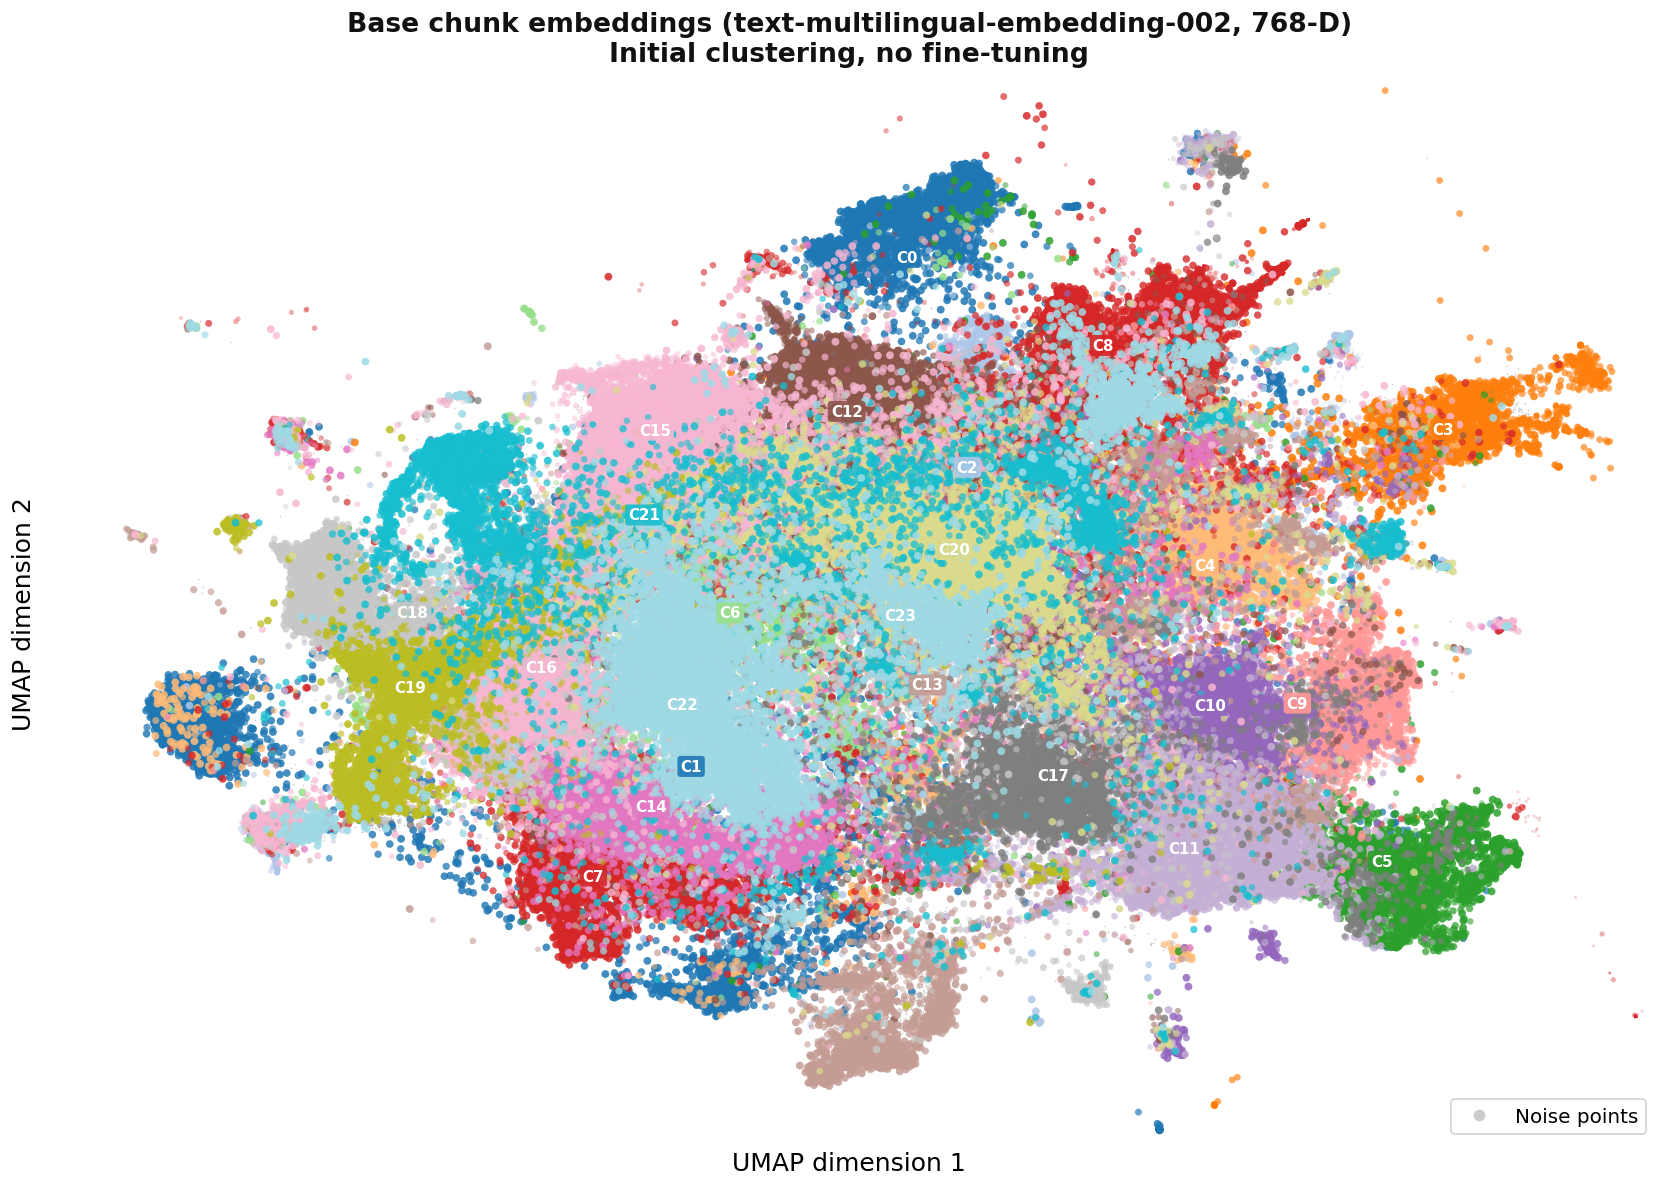

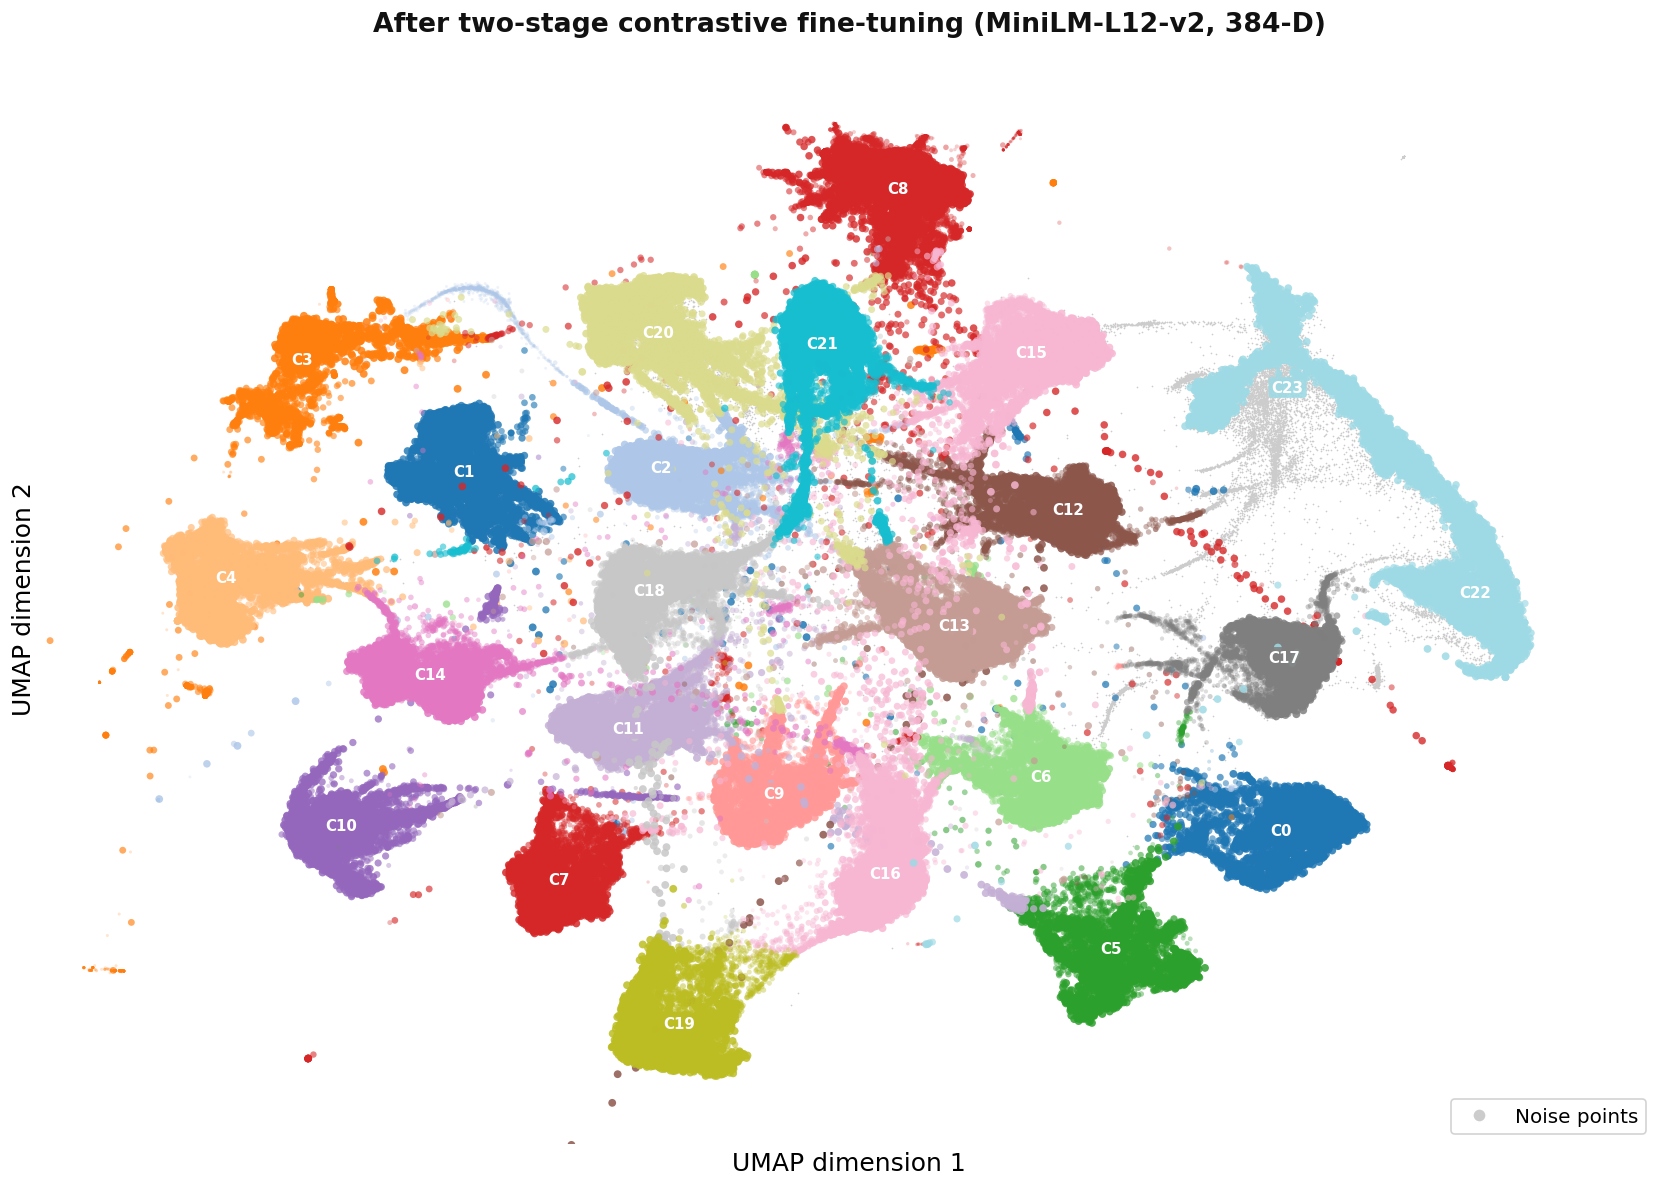

In [4]:
def plot_umap(df, x_col, y_col, title, save_path, show_noise_count=True):
    cluster_ids = sorted(df[df.cluster_id >= 0].cluster_id.unique())
    palette = plt.cm.tab20(np.linspace(0, 1, max(len(cluster_ids), 1)))

    clustered = df[df.cluster_id >= 0]
    x_lo, x_hi = np.percentile(clustered[x_col], [1, 99])
    y_lo, y_hi = np.percentile(clustered[y_col], [1, 99])
    pad_x = (x_hi - x_lo) * 0.12
    pad_y = (y_hi - y_lo) * 0.12

    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    noise = df[df.cluster_id == -1]
    noise_in = noise[(noise[x_col].between(x_lo - pad_x, x_hi + pad_x)) &
                     (noise[y_col].between(y_lo - pad_y, y_hi + pad_y))]
    ax.scatter(noise_in[x_col], noise_in[y_col],
               c='#cccccc', s=1, linewidths=0, zorder=1)

    for cid, color in zip(cluster_ids, palette):
        sub = df[df.cluster_id == cid].copy()
        prob = sub['membership_prob'].fillna(0.5).clip(0.15, 1.0).values
        ax.scatter(sub[x_col], sub[y_col], color=color,
                   s=prob * 22, alpha=np.clip(prob * 0.85, 0.2, 0.9),
                   linewidths=0, zorder=2)
        cx, cy = sub[x_col].median(), sub[y_col].median()
        ax.text(cx, cy, f'C{cid}', fontsize=9, fontweight='bold',
                color='white', ha='center', va='center', zorder=4,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.9, linewidth=0))

    ax.set_xlim(x_lo - pad_x, x_hi + pad_x)
    ax.set_ylim(y_lo - pad_y, y_hi + pad_y)
    ax.set_title(title, fontsize=16, fontweight='bold', color='#111111', pad=12)
    ax.set_xlabel('UMAP dimension 1', fontsize=15)
    ax.set_ylabel('UMAP dimension 2', fontsize=15)

    from matplotlib.lines import Line2D
    n_noise = (df.cluster_id == -1).sum()
    noise_label = 'Noise points'
    ax.legend(
        handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='#cccccc',
                        markersize=8, label=noise_label, linestyle='None')],
        loc='lower right', frameon=True, framealpha=0.85, fontsize=12
    )
    sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()



# base embeddings before fine-tuning; noise label is from the final run, not this pass
plot_umap(df, 'vis_x_base', 'vis_y_base',
          'Base chunk embeddings (text-multilingual-embedding-002, 768-D)\nInitial clustering, no fine-tuning',
          FIGURES_DIR / 'umap_scatter_base.png',
          show_noise_count=False)

# fine-tuned embeddings, final run — 12% noise is the reported figure
plot_umap(df, 'vis_x_fine', 'vis_y_fine',
          'After two-stage contrastive fine-tuning (MiniLM-L12-v2, 384-D)',
          FIGURES_DIR / 'umap_scatter_finetuned.png',
          show_noise_count=True)


## 3. Per-cluster sample chunks

In [5]:
N_SAMPLES = 3
for cid in sorted(df[df.cluster_id >= 0].cluster_id.unique()):
    cluster_rows = df[df.cluster_id == cid][[TEXT_COL]].dropna()
    subset = cluster_rows.sample(min(N_SAMPLES, len(cluster_rows)), random_state=42)
    print(f'\n--- Cluster {cid}  (n={(df.cluster_id==cid).sum()}) ---')
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        snippet = str(row[TEXT_COL])[:250].replace('\n', ' ')
        print(f'  [{i}] {snippet}...')


--- Cluster 0  (n=3956) ---
  [1] [AI]: Salut, Andrei! 😊 Iată pașii pentru a crea un formular pe site-ul tău folosind 10Web AI Builder, astfel încât utilizatorii să poată descărca un ebook și să-l primească pe email:    ### Instrucțiuni:    1. "Adaugă formularul":      - Din pagina "...
  [2] [USER]: Hi. I have installed the FAQ plugin but am unable to find the shortcode. You site says there should be a tab where i can find it but there is nothing there? [AI]: It seems you are looking for the shortcode for the FAQ plugin. Based on the ret...
  [3] [AI]: 4. "Contact Support":      - If the issue persists, you can reach out to our support team for further assistance. [AI]: Let me know if you need detailed guidance on any of these steps! 😊 [AI]: Were my answers helpful to you? I'd love your feedb...

--- Cluster 1  (n=5388) ---
  [1] [USER]: Hello, I need to cancel my plan subscription please. [AI]: To cancel your subscription plan on 10Web, please follow these steps:    1. Click the "Wo

## 4. Top TF-IDF keywords per cluster

In [8]:
N_TERMS  = 10

corpus_by_cluster = (
    df[df.cluster_id >= 0]
    .groupby('cluster_id')[TEXT_COL]
    .apply(lambda texts: ' '.join(texts.dropna().astype(str)))
)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(corpus_by_cluster)
feature_names = tfidf.get_feature_names_out()

print(f'\nTop {N_TERMS} TF-IDF keywords per cluster — {lbl}:\n')
for i, cid in enumerate(corpus_by_cluster.index):
    row    = tfidf_matrix[i].toarray().flatten()
    top_ix = row.argsort()[::-1][:N_TERMS]
    terms  = ', '.join(feature_names[top_ix])
    n      = (df.cluster_id == cid).sum()
    print(f'  Cluster {cid:3d} (n={n:4d}):  {terms}')


Top 10 TF-IDF keywords per cluster — Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d):

  Cluster   0 (n=3956):  ai, user, email, form, smtp, url, plugin, person, 10web, page
  Cluster   1 (n=5388):  ai, user, subscription, 10web, cancel, plan, payment, person, need, cancel subscription
  Cluster   2 (n=7926):  ai, user, 10web, url, person, chat, agent, help, support, ll
  Cluster   3 (n=4115):  ai, user, chat, rate, ll, support, email, nps survey, receive nps, survey email
  Cluster   4 (n=4686):  ai, user, subscription, cancel, person, payment, plan, team, refund, need
  Cluster   5 (n=4021):  ai, domain, dns, email, user, record, records, add, url, txt
  Cluster   6 (n=5213):  ai, user, page, 10web, website, product, ecommerce, woocommerce, products, url
  Cluster   7 (n=5011):  ai, plan, free, 10web, user, trial, website, like, pro, upgrade
  Cluster   8 (n=10499):  ai, user, chat, person, support, agent, ll, thank, help, issue
  Cluster   9 (

## 5. Language distribution per cluster

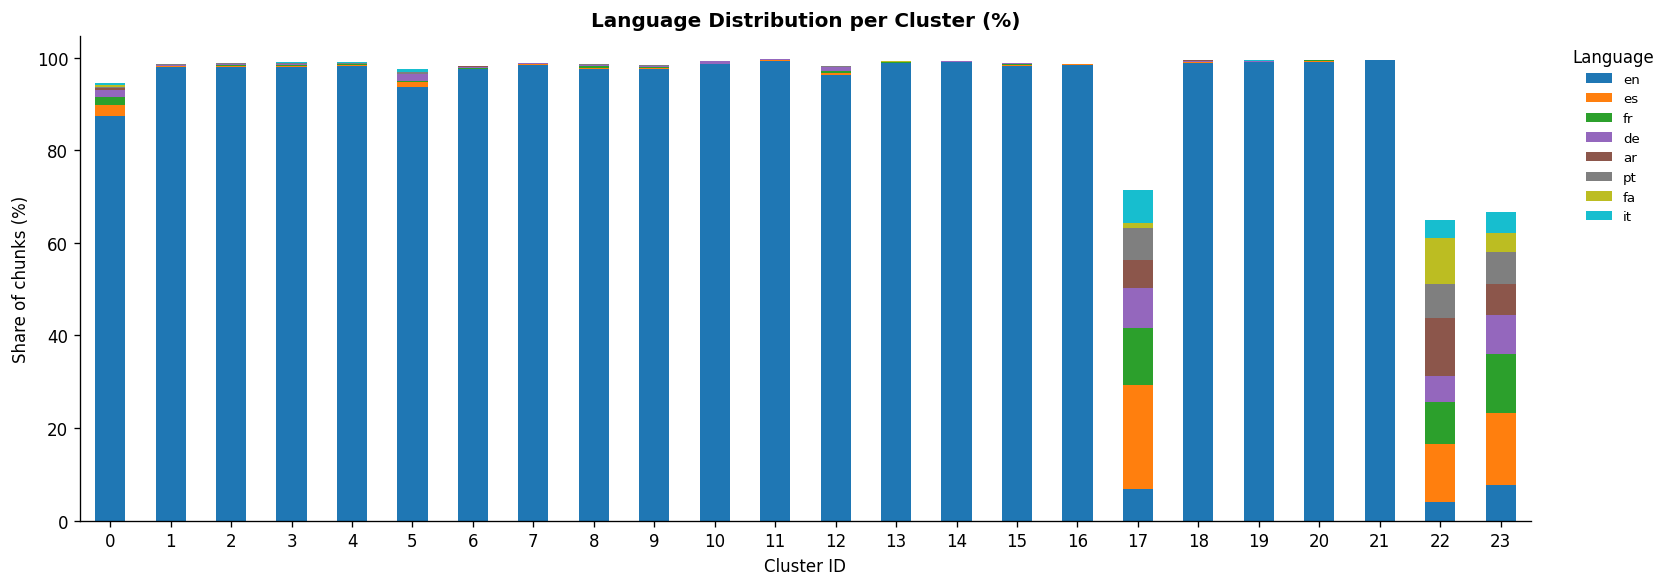

In [9]:
lang_dist = (
    df[df.cluster_id >= 0]
    .groupby(['cluster_id', 'detected_language'])
    .size()
    .reset_index(name='count')
)
pivot = lang_dist.pivot(index='cluster_id', columns='detected_language', values='count').fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)
top_langs = lang_dist.groupby('detected_language')['count'].sum().nlargest(8).index.tolist()
pivot_top  = pivot[[c for c in top_langs if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 5))
pivot_top.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Language Distribution per Cluster (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Share of chunks (%)')
ax.legend(title='Language', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
ax.tick_params(axis='x', rotation=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'language_per_cluster_{TRACK}.png', bbox_inches='tight')
plt.show()